In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent) + "/src-mt"

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/rap/src-mt


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/rap/src-mt/.env


True

In [4]:
import os

model_name = os.getenv("MODEL_NAME")
adapter_name_or_path = os.getenv("ADAPTER_NAME_OR_PATH")
load_in_4bit = os.getenv("LOAD_IN_4BIT") == "true"
data_path = os.getenv("DATA_PATH")
results_path = "results/mac-results_rpp_with_mnt_2048.csv"  # os.getenv("RESULTS_PATH")
use_english_datasets = os.getenv("USE_ENGLISH_DATASETS") == "true"
max_new_tokens = int(os.getenv("MAX_NEW_TOKENS", 2048))

print(
    model_name,
    adapter_name_or_path,
    load_in_4bit,
    data_path,
    results_path,
    use_english_datasets,
    max_new_tokens,
)

microsoft/Phi-3.5-mini-instruct None False datasets/mac/mac.tsv results/mac-results_rpp_with_mnt_2048.csv False 2048


In [5]:
import pandas as pd
from llm_toolkit.llm_utils import *
from llm_toolkit.translation_utils_v2 import *

df = pd.read_csv(results_path)
df.info()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/inflaton/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/inflaton/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/inflaton/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


loading: /Users/inflaton/code/engd/papers/rap/src-mt/eval_modules/calc_repetitions.py
loading /Users/inflaton/code/engd/papers/rap/src-mt/llm_toolkit/translation_utils_v2.py


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/inflaton/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/inflaton/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/inflaton/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.0.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../../../../.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/f49d328952c3470eff6bb6f545d62bfdb6e66304/checkpoints/model.ckpt`
Encoder model frozen.
/Users/inflaton/anaconda3/envs/rap/lib/python3.11/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 44 columns):
 #   Column                                                            Non-Null Count  Dtype 
---  ------                                                            --------------  ----- 
 0   chinese                                                           1133 non-null   object
 1   english                                                           1133 non-null   object
 2   internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.00              1133 non-null   object
 3   internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.02              1133 non-null   object
 4   internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.04              1133 non-null   object
 5   internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.06              1133 non-null   object
 6   internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.08              1133 non-null   object
 7   internlm/internlm2_5-7b-chat/checkpoint-14

In [6]:
result_columns = [col for col in df.columns[2:].to_list() if "rpp" in col]
result_columns.sort()
result_columns

['Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.00',
 'Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.02',
 'Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.04',
 'Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.06',
 'Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.08',
 'Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.10',
 'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.00',
 'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.02',
 'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.04',
 'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.06',
 'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.08',
 'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.10',
 'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.00',
 'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.02',
 'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.04',
 'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.06',
 'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.08',
 'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.10',
 'microsoft/Phi-3.5-mini-instruct/checkp

In [7]:
columns = df.columns[:2].to_list() + result_columns
df = df[columns]
columns = df.columns.to_list()
result_columns = df.columns[2:].to_list()
result_columns, columns

(['Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.00',
  'Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.02',
  'Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.04',
  'Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.06',
  'Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.08',
  'Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.10',
  'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.00',
  'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.02',
  'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.04',
  'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.06',
  'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.08',
  'Qwen/Qwen2-7B-Instruct/checkpoint-105/rpp-1.10',
  'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.00',
  'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.02',
  'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.04',
  'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.06',
  'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.08',
  'internlm/internlm2_5-7b-chat/checkpoint-140/rpp-1.10',
  'microsoft/Phi-3.5-m

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 44 columns):
 #   Column                                                            Non-Null Count  Dtype 
---  ------                                                            --------------  ----- 
 0   chinese                                                           1133 non-null   object
 1   english                                                           1133 non-null   object
 2   Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.00                   1133 non-null   object
 3   Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.02                   1133 non-null   object
 4   Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.04                   1133 non-null   object
 5   Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.06                   1133 non-null   object
 6   Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.08                   1133 non-null   object
 7   Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp

In [9]:
metrics_path = results_path.replace(".csv", "_metrics.csv")
metrics_df = pd.read_csv(metrics_path) if os.path.exists(metrics_path) else None
metrics_df.info() if metrics_df is not None else None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   model                           42 non-null     object 
 1   rpp                             42 non-null     float64
 2   comet                           42 non-null     float64
 3   meteor                          42 non-null     float64
 4   spbleu                          42 non-null     float64
 5   bleu_1                          42 non-null     float64
 6   rouge_l                         42 non-null     float64
 7   ews_score                       42 non-null     float64
 8   newline_score                   42 non-null     float64
 9   repetition_score                42 non-null     float64
 10  total_repetitions               42 non-null     float64
 11  rr                              42 non-null     float64
 12  rrp                             42 non

In [10]:
%%time

variant = "rpp"
metrics_df = get_metrics(
    df,
    max_output_tokens=max_new_tokens,
    variant=variant,
    existing_metrics_df=metrics_df,
)
metrics_df

['Qwen/Qwen2-72B-Instruct', 'Qwen/Qwen2-7B-Instruct', 'internlm/internlm2_5-7b-chat', 'microsoft/Phi-3.5-mini-instruct', 'shenzhi-wang/Llama3.1-70B-Chinese-Chat', 'shenzhi-wang/Llama3.1-8B-Chinese-Chat', 'shenzhi-wang/Mistral-7B-v0.3-Chinese-Chat']
['Qwen/Qwen2-72B-Instruct/checkpoint-560', '1.00']
Using existing metrics for Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.00
Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.00: {'model': 'Qwen/Qwen2-72B-Instruct', 'rpp': 1.0, 'comet': 0.7570170721487987, 'meteor': 0.4789208192601603, 'spbleu': 18.953782447211417, 'bleu_1': 0.1895378244721141, 'rouge_l': 0.4522514493620528, 'ews_score': 0.0785525154457193, 'newline_score': 0.0785525154457193, 'repetition_score': 0.0626654898499558, 'total_repetitions': 0.1412180052956752, 'rr': 0.0012165820128349, 'rrp': 0.121658201283494, 'perf': 0.7570170721487987, 'rap': 0.7542575120443845, 'translation_completeness': 1.0, 'num_max_output_tokens': 0, 'percentage_of_repeated_entries': 2.206531332744925}
['Qwe

,model,rpp,comet,meteor,spbleu,bleu_1,rouge_l,ews_score,newline_score,repetition_score,total_repetitions,rr,rrp,perf,rap,translation_completeness,num_max_output_tokens,percentage_of_repeated_entries
0,Qwen/Qwen2-72B-Instruct,1.00,0.757017,0.478921,18.953782,0.189538,0.452251,0.078553,0.078553,0.062665,0.141218,0.001217,0.121658,0.757017,0.754258,1.000000,0,2.206531
1,Qwen/Qwen2-72B-Instruct,1.02,0.757358,0.479684,19.013749,0.190137,0.452692,0.099735,0.099735,0.074139,0.173875,0.001496,0.149565,0.757358,0.753965,1.000000,0,2.647838
2,Qwen/Qwen2-72B-Instruct,1.04,0.757499,0.476363,18.520633,0.185206,0.449179,0.083848,0.083848,0.086496,0.170344,0.001461,0.146111,0.757499,0.754183,1.000000,0,2.471315
3,Qwen/Qwen2-72B-Instruct,1.06,0.756385,0.467964,17.982474,0.179825,0.441430,0.073257,0.073257,0.054722,0.127979,0.001083,0.108299,0.756385,0.753930,1.000000,0,2.118270
4,Qwen/Qwen2-72B-Instruct,1.08,0.755447,0.459758,17.067954,0.170680,0.431905,0.063548,0.063548,0.037952,0.101500,0.000850,0.085003,0.755447,0.753522,1.000000,0,1.853486
5,Qwen/Qwen2-72B-Instruct,1.10,0.755010,0.451578,16.224522,0.162245,0.424476,0.057370,0.057370,0.028244,0.085613,0.000712,0.071214,0.755010,0.753398,1.000000,0,1.676964
6,Qwen/Qwen2-7B-Instruct,1.00,0.745772,0.442241,14.388149,0.143881,0.416276,0.058252,0.058252,10.774934,10.833186,0.083960,8.396038,0.745772,0.573257,0.994704,2,2.294793
7,Qwen/Qwen2-7B-Instruct,1.02,0.747408,0.440100,15.161723,0.151617,0.416504,0.056487,0.056487,7.036187,7.092674,0.057428,5.742830,0.747408,0.625894,0.994704,1,2.294793
8,Qwen/Qwen2-7B-Instruct,1.04,0.748438,0.439014,14.958632,0.149586,0.414297,0.052957,0.052957,0.108561,0.161518,0.001380,0.137985,0.748438,0.745344,0.999117,0,1.853486
9,Qwen/Qwen2-7B-Instruct,1.06,0.747161,0.432832,14.280874,0.142809,0.407332,0.067079,0.067079,0.110327,0.177405,0.001511,0.151139,0.747161,0.743779,0.998235,0,2.206531


In [11]:
metrics_df.to_csv(metrics_path, index=False)
metrics_df.describe()

,comet,meteor,spbleu,bleu_1,rouge_l,ews_score,newline_score,repetition_score,total_repetitions,rr,rrp,perf,rap,translation_completeness,num_max_output_tokens,percentage_of_repeated_entries
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,0.736585,0.418134,13.836401,0.138364,0.394040,0.552431,0.552431,2.659417,3.211848,0.025383,2.538284,0.736585,0.685880,0.999622,0.547619,2.086748
std,0.018671,0.042615,3.443285,0.034433,0.043082,1.837656,1.837656,4.393706,5.523942,0.041589,4.158920,0.018671,0.084562,0.001172,1.063872,0.800148
min,0.671299,0.290383,4.091959,0.040920,0.251653,0.000000,0.000000,0.028244,0.085613,0.000712,0.071214,0.671299,0.360853,0.994704,0.000000,1.235658
25%,0.727631,0.402094,12.868566,0.128686,0.381652,0.010591,0.010591,0.085834,0.136364,0.001164,0.116369,0.727631,0.629587,1.000000,0.000000,1.676964
50%,0.742645,0.427084,14.334512,0.143345,0.403171,0.056487,0.056487,0.129744,0.175640,0.001545,0.154519,0.742645,0.724005,1.000000,0.000000,2.030009
75%,0.748180,0.443718,16.025109,0.160251,0.418761,0.071271,0.071271,5.652692,5.698588,0.047846,4.784616,0.748180,0.745240,1.000000,1.000000,2.294793
max,0.757499,0.479684,19.013749,0.190137,0.452692,10.670786,10.670786,17.938217,28.609003,0.202255,20.225504,0.757499,0.754258,1.000000,6.000000,6.443071


In [12]:
models = metrics_df["model"].unique()
models

array(['Qwen/Qwen2-72B-Instruct', 'Qwen/Qwen2-7B-Instruct',
       'internlm/internlm2_5-7b-chat', 'microsoft/Phi-3.5-mini-instruct',
       'shenzhi-wang/Llama3.1-70B-Chinese-Chat',
       'shenzhi-wang/Llama3.1-8B-Chinese-Chat',
       'shenzhi-wang/Mistral-7B-v0.3-Chinese-Chat'], dtype=object)

In [13]:
# list of markers for plotting
markers = [
    "o",
    "x",
    "^",
    "s",
    "d",
    "P",
    "X",
    "*",
    "v",
    ">",
    "<",
    "p",
    "h",
    "H",
    "+",
    "|",
    "_",
]
markers = {model: marker for model, marker in zip(models, markers)}

In [14]:
model_orders = {
    "microsoft/Phi-3.5-mini-instruct": 5,
    "internlm/internlm2_5-7b-chat": 10,
    "Qwen/Qwen2-7B-Instruct": 20,
    "shenzhi-wang/Mistral-7B-v0.3-Chinese-Chat": 30,
    "shenzhi-wang/Llama3.1-8B-Chinese-Chat": 40,
    "shenzhi-wang/Llama3.1-70B-Chinese-Chat": 50,
    "Qwen/Qwen2-72B-Instruct": 60,
    "gpt-4o-mini": 99,
    "gpt-4o": 100,
}

In [15]:
# plot mtr vs rpp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_metrics_vs_rpp(
    metrics_df,
    models,
    markers,
    columns,
    titles,
    log_scales=[False, False],
    sync_y_axis=False,
):
    fig, ax = plt.subplots(figsize=(10, 6))
    # set grid
    ax.grid(True)
    ax.set_axisbelow(True)
    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", linewidth="0.5", color="red")

    # Create a mapping from original x-values to new, evenly spaced x-values
    original_x_values = sorted(metrics_df[variant].unique())
    new_x_values = range(len(original_x_values))
    x_mapping = dict(zip(original_x_values, new_x_values))

    if len(columns) > 1:
        twin = ax.twinx()

    for model in models:
        model_df = metrics_df[metrics_df["model"] == model]
        transformed_x = [x_mapping[x] for x in model_df[variant]]
        for i, column in enumerate(columns):
            current_ax = twin if i > 0 else ax
            current_ax.plot(
                transformed_x,
                model_df[column],
                label=model + f" [{titles[i]}]" if titles else "",
                marker=markers[model],
                linestyle="--" if i > 0 else "-",
            )
            current_ax.set_ylabel(titles[i])
            if log_scales[i]:
                current_ax.set_yscale("log")

    if sync_y_axis:
        ax.set_ylim(
            min(ax.get_ylim()[0], twin.get_ylim()[0]),
            max(ax.get_ylim()[1], twin.get_ylim()[1]),
        )
        twin.set_ylim(ax.get_ylim())

    # Set the x-axis ticks to be evenly spaced
    ax.xaxis.set_major_locator(ticker.FixedLocator(new_x_values))

    # Set custom labels for the ticks
    ax.xaxis.set_major_formatter(ticker.FixedFormatter(original_x_values))

    # ax.set_ylim(0, 1)
    ax.set_xlabel("Repetition Penalty Parameter (RPP)")
    handles, labels = ax.get_legend_handles_labels()

    if len(columns) > 1:
        handles_twin, labels_twin = twin.get_legend_handles_labels()
        handles += handles_twin
        labels += labels_twin

    # Sort the handles and labels by labels
    sorted_handles_labels = sorted(
        zip(labels, handles), key=lambda x: model_orders[x[0].split(" ")[0]]
    )
    sorted_labels, sorted_handles = zip(*sorted_handles_labels)

    # Create a combined legend
    ax.legend(
        sorted_handles,
        sorted_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.75 if len(columns) > 1 else -0.435),
    )

    plt.show()

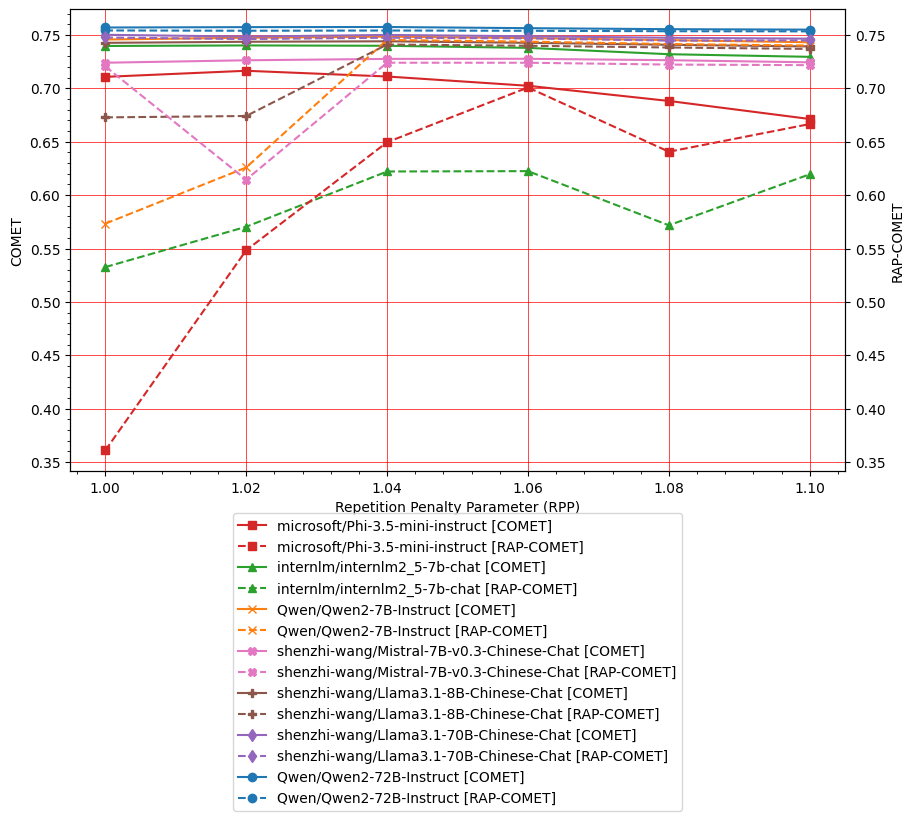

In [16]:
plot_metrics_vs_rpp(
    metrics_df,
    models,
    markers,
    ["comet", "rap"],
    ["COMET", "RAP-COMET"],
    sync_y_axis=True,
)

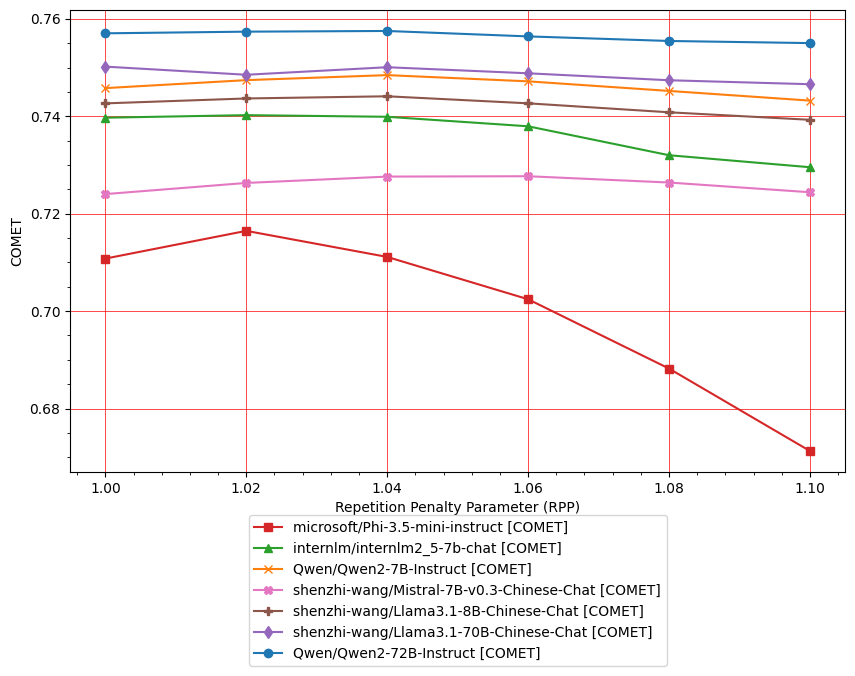

In [17]:
plot_metrics_vs_rpp(
    metrics_df,
    models,
    markers,
    ["comet"],
    ["COMET"],
)

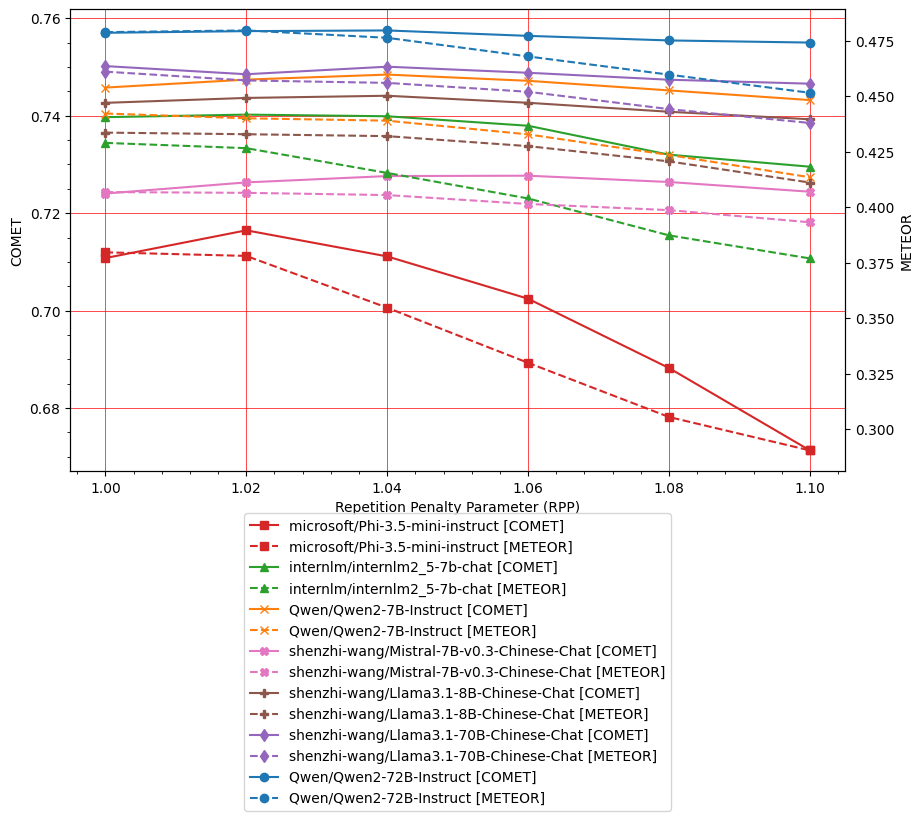

In [18]:
plot_metrics_vs_rpp(
    metrics_df,
    models,
    markers,
    ["comet", "meteor"],
    ["COMET", "METEOR"],
)

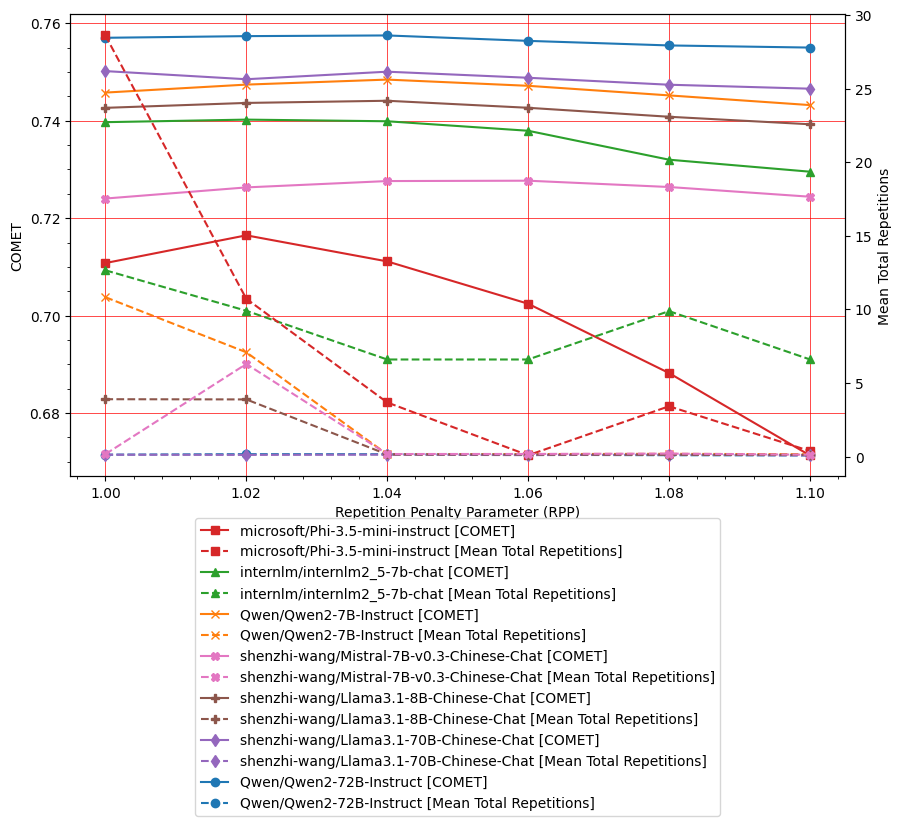

In [19]:
plot_metrics_vs_rpp(
    metrics_df,
    models,
    markers,
    ["comet", "total_repetitions"],
    ["COMET", "Mean Total Repetitions"],
)

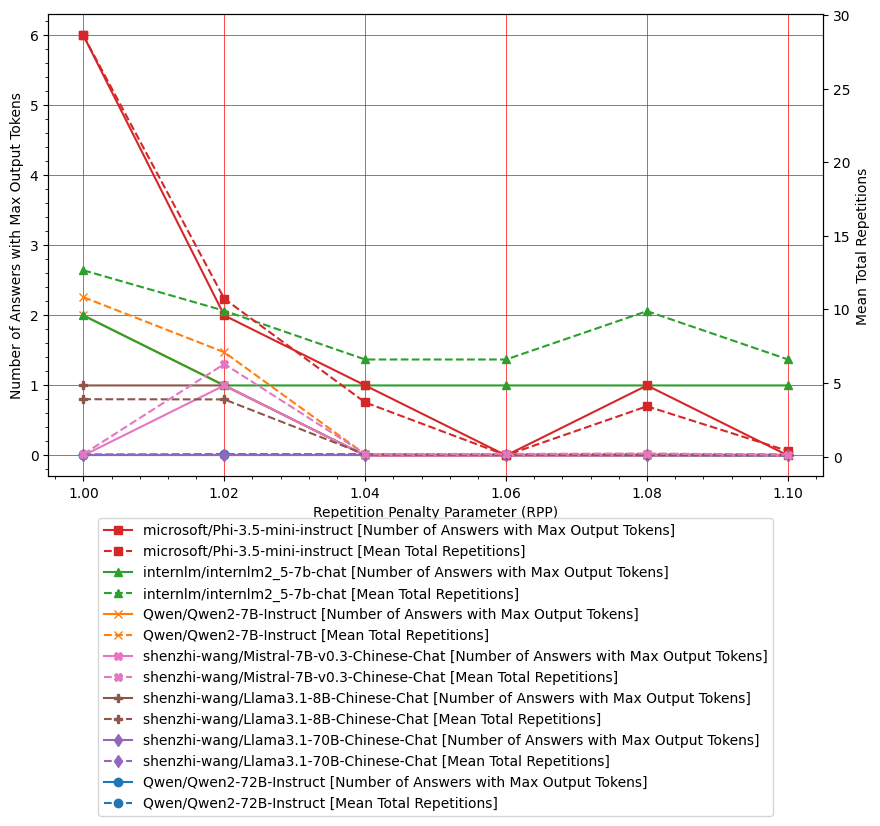

In [20]:
plot_metrics_vs_rpp(
    metrics_df,
    models,
    markers,
    ["num_max_output_tokens", "total_repetitions"],
    ["Number of Answers with Max Output Tokens", "Mean Total Repetitions"],
)

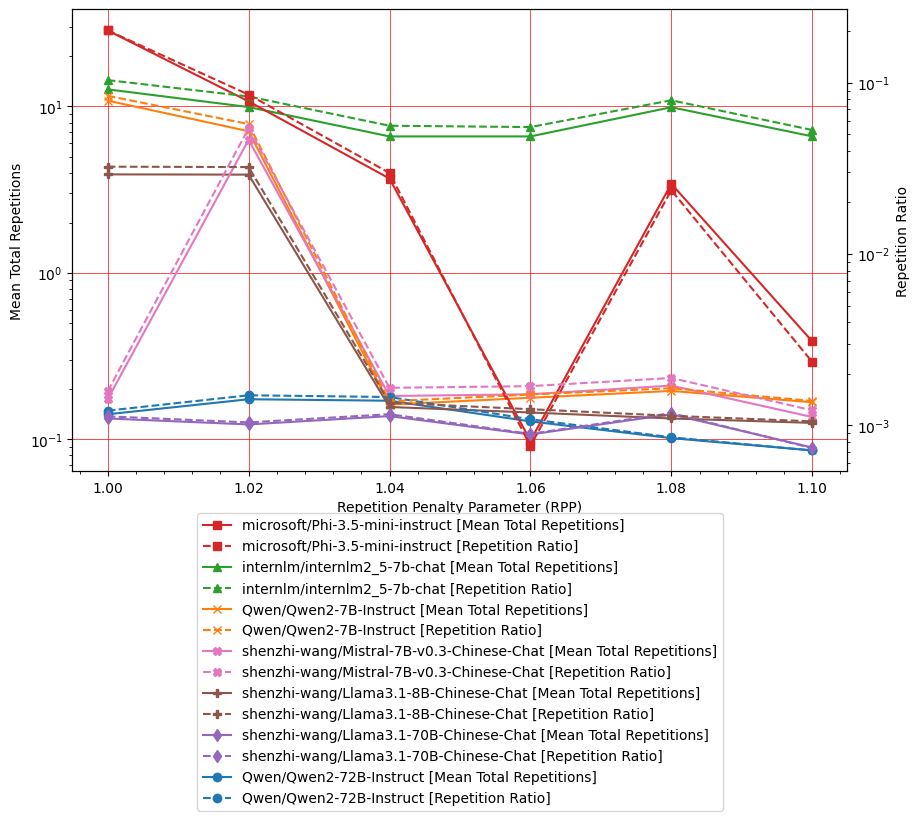

In [21]:
plot_metrics_vs_rpp(
    metrics_df,
    models,
    markers,
    ["total_repetitions", "rr"],
    ["Mean Total Repetitions", "Repetition Ratio"],
    [True, True],
)

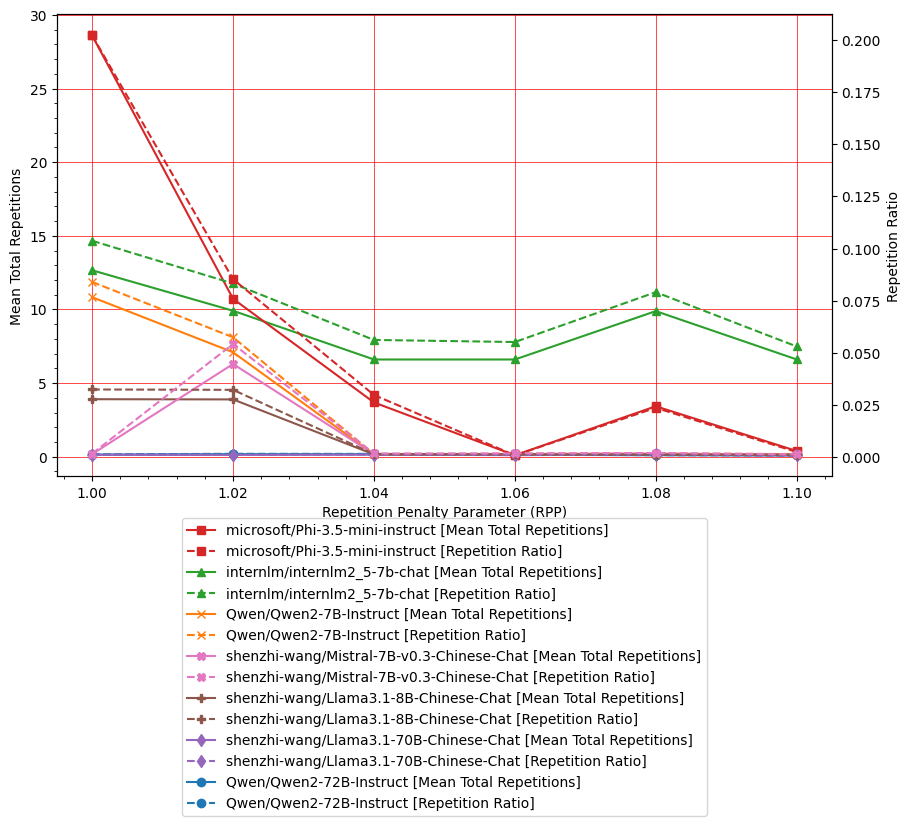

In [22]:
plot_metrics_vs_rpp(
    metrics_df,
    models,
    markers,
    ["total_repetitions", "rr"],
    ["Mean Total Repetitions", "Repetition Ratio"],
    # [True, True],
)

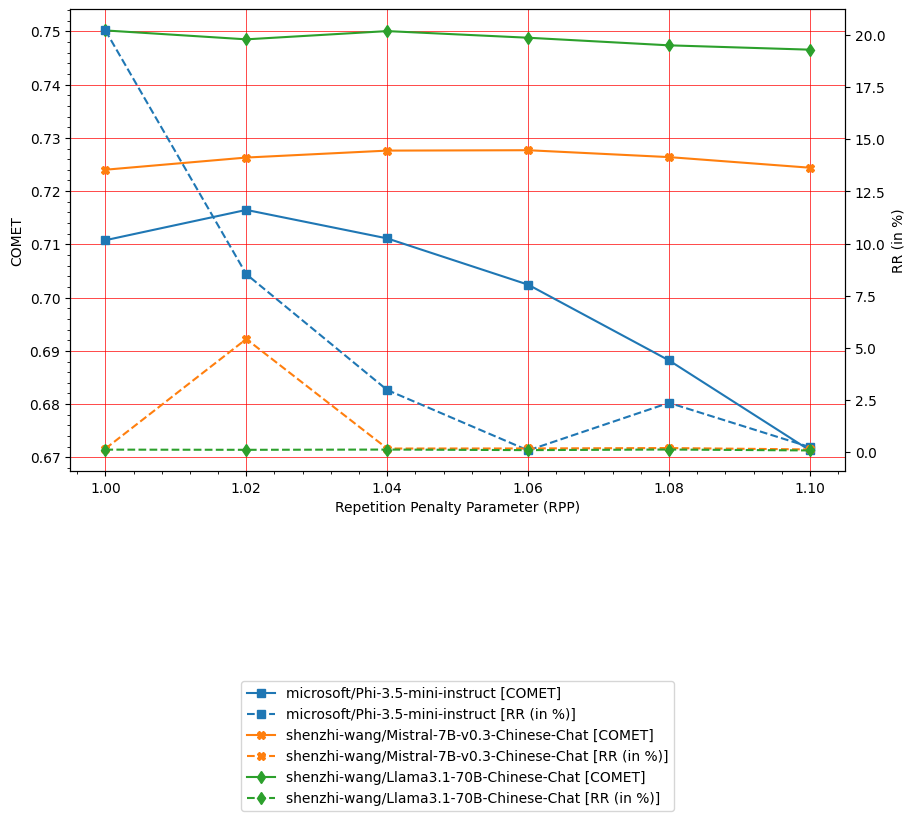

In [23]:
plot_metrics_vs_rpp(
    metrics_df,
    ['microsoft/Phi-3.5-mini-instruct', 'shenzhi-wang/Mistral-7B-v0.3-Chinese-Chat', 'shenzhi-wang/Llama3.1-70B-Chinese-Chat'],
    markers,
    ["comet", "rrp"],
    ["COMET", "RR (in %)"],
    # [True, True],
)

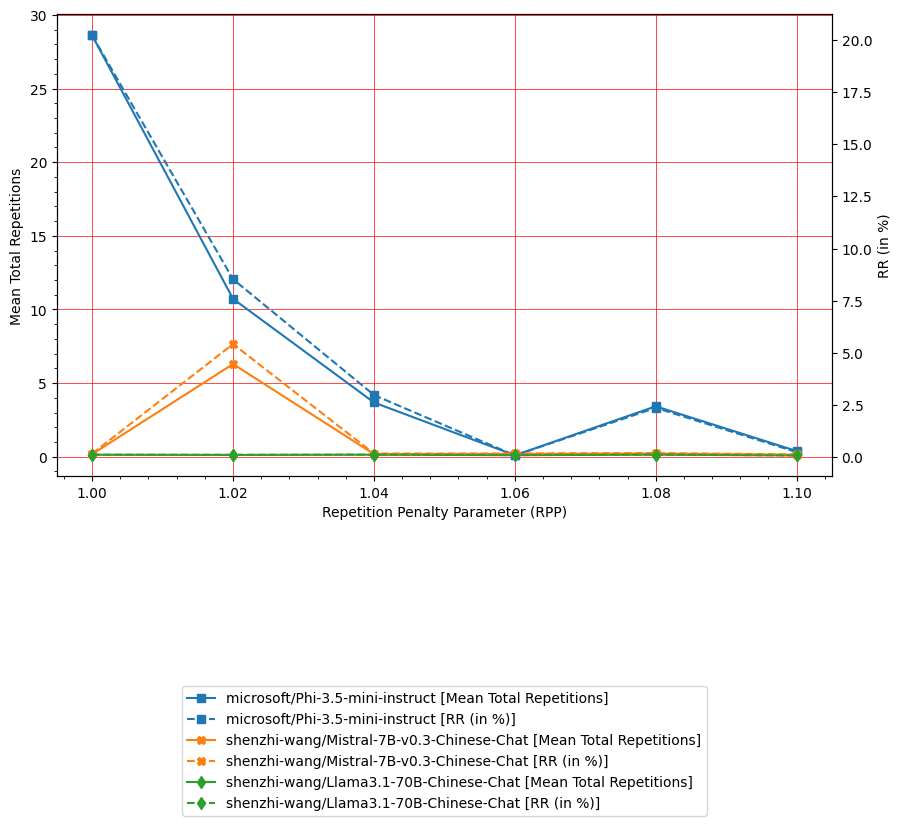

In [24]:
plot_metrics_vs_rpp(
    metrics_df,
    ['microsoft/Phi-3.5-mini-instruct', 'shenzhi-wang/Mistral-7B-v0.3-Chinese-Chat', 'shenzhi-wang/Llama3.1-70B-Chinese-Chat'],
    markers,
    ["total_repetitions", "rrp"],
    ["Mean Total Repetitions", "RR (in %)"],
    # [True, True],
)

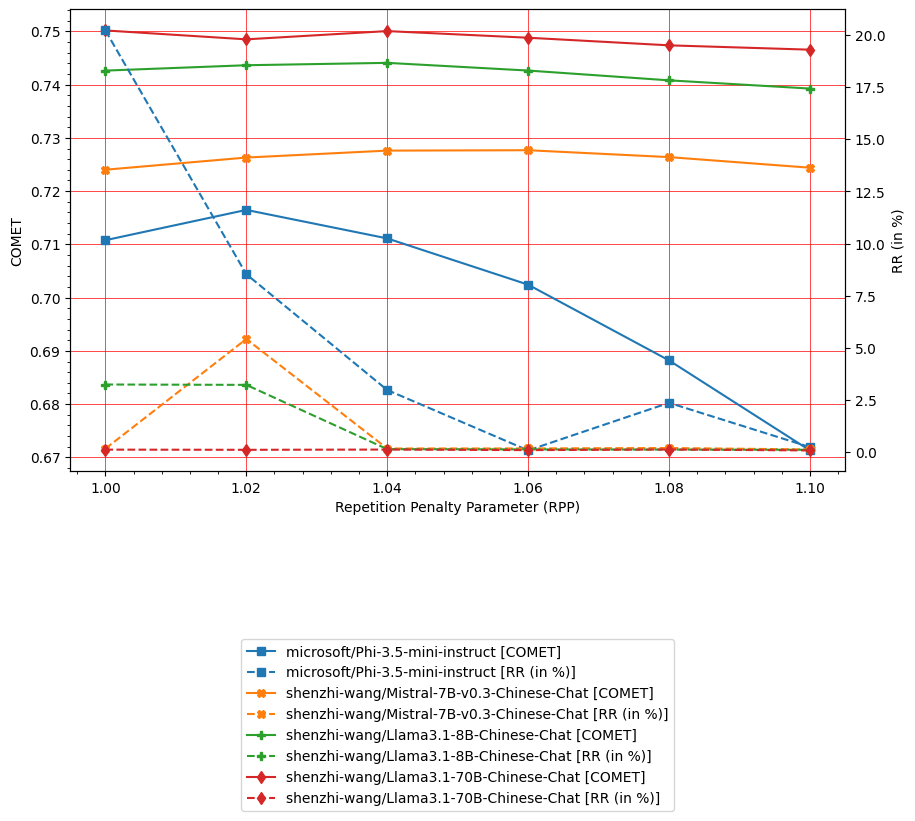

In [25]:
plot_metrics_vs_rpp(
    metrics_df,
    ['microsoft/Phi-3.5-mini-instruct', 'shenzhi-wang/Mistral-7B-v0.3-Chinese-Chat', 'shenzhi-wang/Llama3.1-8B-Chinese-Chat', 'shenzhi-wang/Llama3.1-70B-Chinese-Chat'],
    markers,
    ["comet", "rrp"],
    ["COMET", "RR (in %)"],
    # [True, True],
)

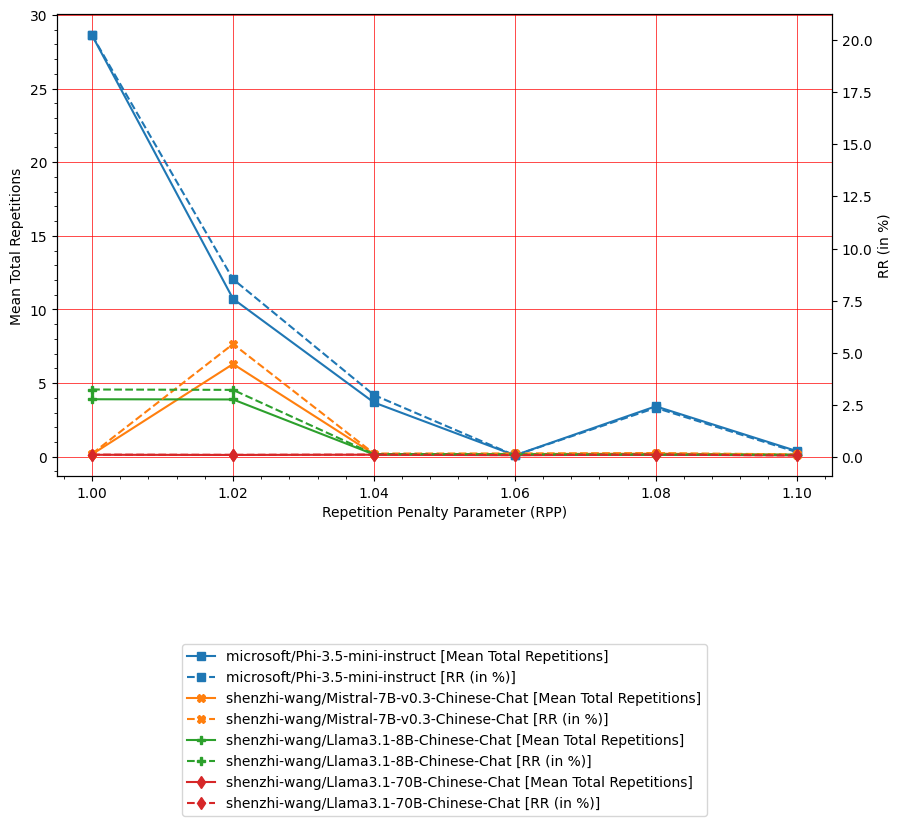

In [26]:
plot_metrics_vs_rpp(
    metrics_df,
    ['microsoft/Phi-3.5-mini-instruct', 'shenzhi-wang/Mistral-7B-v0.3-Chinese-Chat', 'shenzhi-wang/Llama3.1-8B-Chinese-Chat', 'shenzhi-wang/Llama3.1-70B-Chinese-Chat'],
    markers,
    ["total_repetitions", "rrp"],
    ["Mean Total Repetitions", "RR (in %)"],
    # [True, True],
)

In [27]:
for col in result_columns:
    print(f"### Analyzing: {col}")
    analyze_translation_results(
        df, col, repetition_threshold=50, max_new_tokens=max_new_tokens
    )

### Analyzing: Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.00
*** Found 0 rows with total_repetitions > 50 for Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.00

*** Found 0 rows with output_tokens >= 2048 for Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.00

*** Found 0 rows with incomplete translations for Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.00
### Analyzing: Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.02
*** Found 0 rows with total_repetitions > 50 for Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.02

*** Found 0 rows with output_tokens >= 2048 for Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.02

*** Found 0 rows with incomplete translations for Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.02
### Analyzing: Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.04
*** Found 0 rows with total_repetitions > 50 for Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.04

*** Found 0 rows with output_tokens >= 2048 for Qwen/Qwen2-72B-Instruct/checkpoint-560/rpp-1.04

*** Found 0 rows with incomple